### Получаем данные

In [2]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 49/49 [00:47<00:00,  1.02it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024669,2026-03-23 18:59:35,71025.000000,71025.203125,71023.703125,71024.000000,0.145,0.000,0.000,0.000,0.000000,...,0.009,0.002,0.002,0.004,0.677,0.035,0.003,0.002,0.002,0.002
1024670,2026-03-23 18:59:40,71042.398438,71045.000000,71029.296875,71034.601562,11.150,8.273,7.907,0.366,0.911519,...,0.002,0.002,0.016,0.002,0.606,0.519,0.003,0.042,0.002,0.006
1024671,2026-03-23 18:59:45,71049.101562,71050.101562,71039.796875,71047.601562,0.250,0.125,0.068,0.057,0.088000,...,0.576,0.268,0.002,0.012,3.379,0.511,0.033,0.004,0.002,0.031
1024672,2026-03-23 18:59:50,71035.000000,71039.000000,71034.703125,71035.101562,4.598,1.787,0.000,1.787,-1.000000,...,0.002,0.054,0.035,0.002,0.214,0.517,0.002,0.002,0.016,0.004


### Определяем таргеты для всех моделей

In [3]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 1024673/1024673 [00:09<00:00, 113144.06it/s]


### Генерируем фичи для всех моделей

In [4]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.147772,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.140313,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.140313,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.136624,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.144127,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024669,10.882812,0.316438,16.596274,16.783704,5.387018e-07,10.882797,0.136805,-0.004866,0.026680,-0.270876,...,0.572449,0.105041,0.193419,0.147917,0.258663,71023.703125,71025.203125,71024.000000,0.000185,0.000221
1024670,11.196094,0.415078,16.743065,16.927929,5.302394e-07,11.196078,0.655859,-0.238029,-0.180260,-12.242726,...,0.587240,0.858539,-0.780973,-0.162994,0.430871,71029.296875,71045.000000,71034.601562,0.000146,0.000145
1024671,11.602734,0.064797,16.701630,16.873118,4.434097e-07,11.602718,0.441133,0.188313,0.078633,14.837540,...,0.610823,1.802899,1.136911,-0.103966,-0.119087,71039.796875,71050.101562,71047.601562,-0.000151,0.000060
1024672,11.536068,0.603703,16.574857,16.635814,2.430047e-06,11.536051,1.095703,-1.410077,-0.329031,-20.634923,...,0.613045,1.527484,-0.985532,0.754091,0.788960,71034.703125,71039.000000,71035.101562,-0.000058,0.000117


In [5]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [6]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=13,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00016
[250]	validation_0-rmse:0.00016
[300]	validation_0-rmse:0.00016
[350]	validation_0-rmse:0.00016
[400]	validation_0-rmse:0.00016
[450]	validation_0-rmse:0.00016
[500]	validation_0-rmse:0.00016
[550]	validation_0-rmse:0.00016
[600]	validation_0-rmse:0.00016
[650]	validation_0-rmse:0.00016
[700]	validation_0-rmse:0.00016
[750]	validation_0-rmse:0.00016
[769]	validation_0-rmse:0.00016
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000096
RMSE                     : 0.000156
R²                       : 0.283154
MAE / mean|Δ|            : 0.815601
RMSE / RMSE_base         : 0.846656
mean|Δ| (target)         : 0.000117

------------------------------------------------------------
Directional Accuracy     : 0.637966
Target Pos Ratio         : 0.473745
Profit Factor            : 1.693767
Avg Gain (correct)       : -0.000003
Avg Loss (incorrect)     : 0.000004

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6361, 0.6397)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
           quantile  confidence  directional_acc  mean_return  n_samples
(0.000127, 0.00166]    0.000230         0.924774    -0.000006      25616
(6.9e-05, 0.000127]    0.000093         0.825187    -0.000003      25616
(4.32e-05, 6.9e-05]    0.000055         0.741060    -0.000001      25616


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


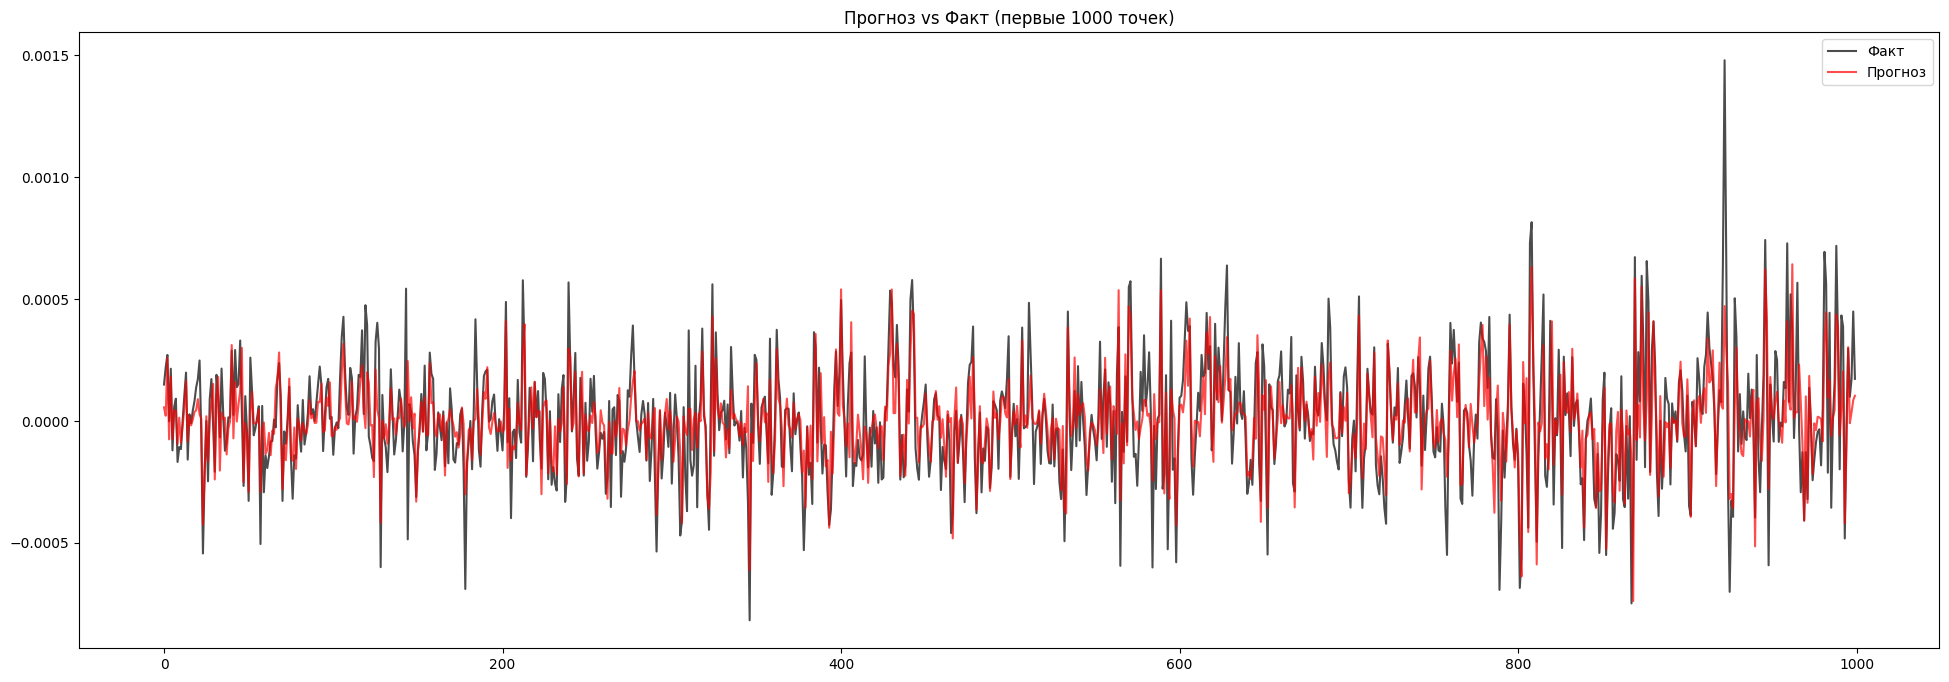

In [7]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [8]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=8,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[724]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000102
RMSE                     : 0.000153
R²                       : 0.418675
MAE / mean|Δ|            : 0.585668
RMSE / RMSE_base         : 0.576285
mean|Δ| (target)         : 0.000174

------------------------------------------------------------
Directional Accuracy     : 0.894964
Target Pos Ratio         : 0.894964
Profit Factor            : 44510049735.151138
Avg Gain (correct)       : 0.000194
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8938, 0.8961)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
  (0.00034, 0.00316]    0.000466         0.999844     0.000461      25616
 (0.000251, 0.00034]    0.000291         0.996916     0.000287      25616
(0.000203, 0.000251]    0.000225         0.987937     0.000223    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


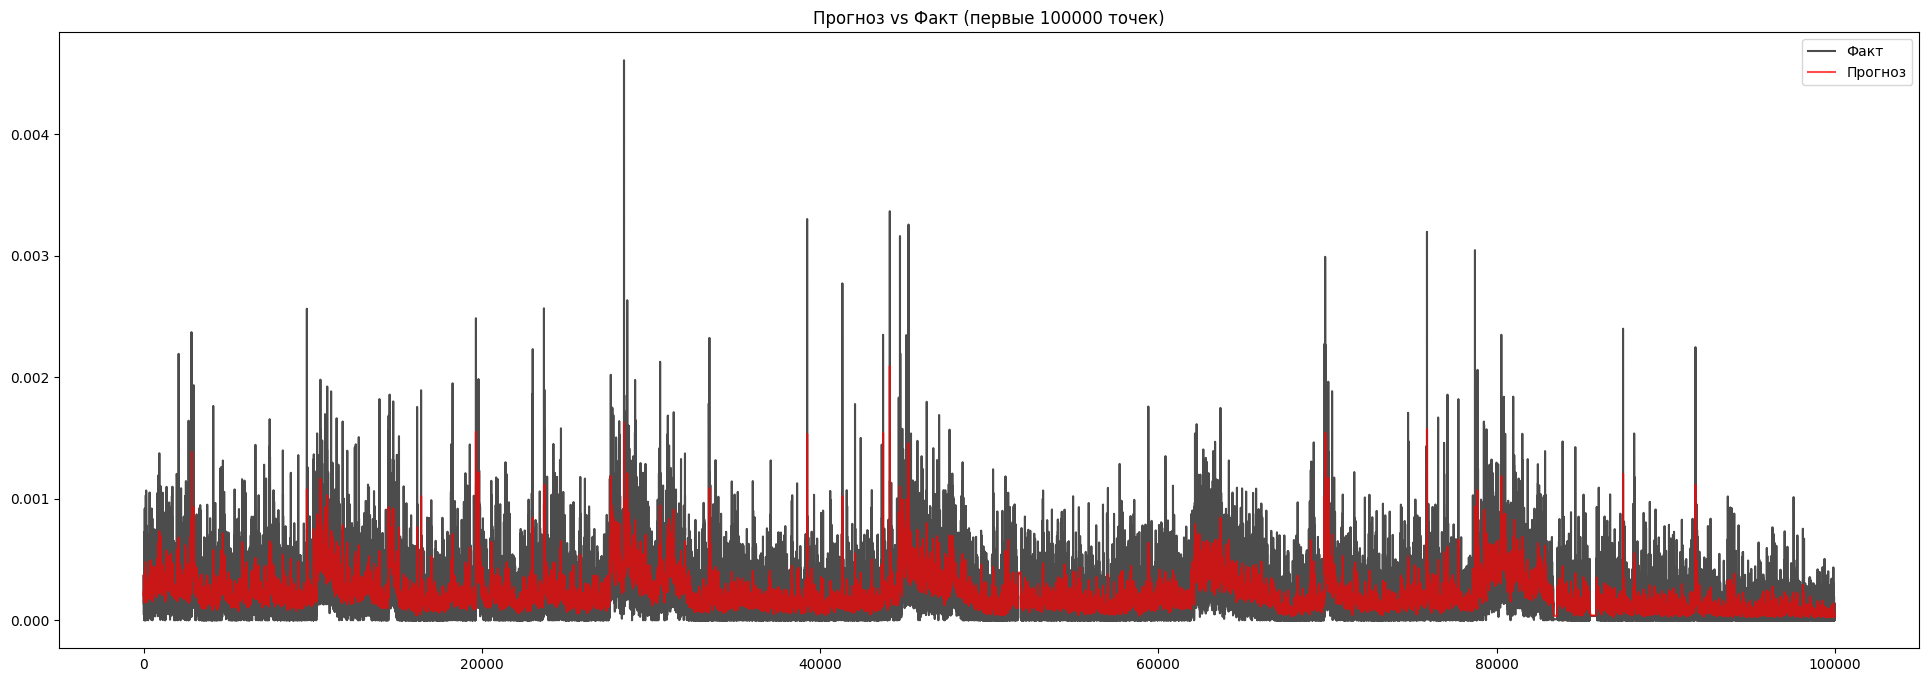

In [9]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)